In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.chdir('/content/drive/MyDrive/NLP CW - PG')

## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import pickle
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

## Load test data

In [4]:
test_df = pd.read_csv("data/test.csv")
X_test = test_df["text"]
y_test = test_df["label"]

In [5]:
print("Columns in test_df:", test_df.columns.tolist())
display(test_df.head())

Columns in test_df: ['text', 'label']


,text,label
0,modi keeps doing this bizarre thing when he po...,1
1,this man has been sending letters to the ocean...,1
2,products every elephant lover needs in their ...,1
3,elmos twitter is lit af,1
4,will ferrell hilariously acted like a cat for ...,1


## 1. Load First Best Model - LSTM with Adam optimizer

In [6]:
# Load model
model_adam = load_model("models/lstm_adam.h5")
# Load tokenizer
with open("models/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [7]:
#padding length
max_length = 50  #same as training

X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

#### Predict and Evaluate

In [8]:
probs_adam = model_adam.predict(X_test_pad)
y_pred_adam = (probs_adam>0.5).astype("int32")
lstm_results_df = pd.DataFrame({'headlines': X_test, 'y_test': y_test, 'y_pred_adam': y_pred_adam.flatten()})
lstm_results_df.to_csv("lstm_predictions.csv", index=False)

200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step


Accuracy: 0.96921875

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      3200
           1       0.98      0.96      0.97      3200

    accuracy                           0.97      6400
   macro avg       0.97      0.97      0.97      6400
weighted avg       0.97      0.97      0.97      6400


Confusion Matrix (LSTM (Adam)):


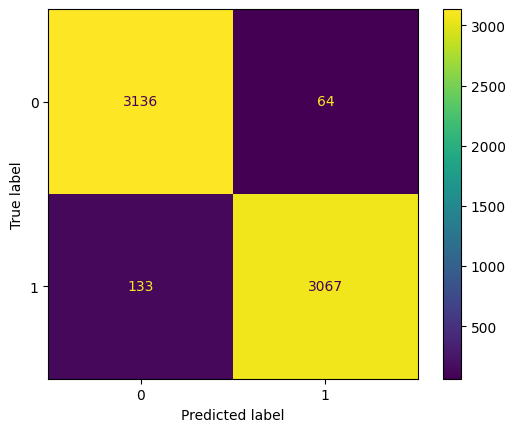

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred_adam))
print("\nClassification Report:\n",classification_report(y_test, y_pred_adam))
print("\nConfusion Matrix (LSTM (Adam)):\n", ConfusionMatrixDisplay.from_predictions(y_test, y_pred_adam))

## 2. Load Second Best Model : TF-IDF + SVM

In [10]:
#load pipeline
with open("models/svm_tfidf_pipeline.pkl", "rb") as f:
    best_svm = pickle.load(f)
# Predict
y_pred_svm = best_svm.predict(X_test)
svm_results_df = pd.DataFrame({'headlines': X_test, 'y_test': y_test, 'y_pred_svm': y_pred_svm})
svm_results_df.to_csv("svm_tfidf_predictions.csv", index=False)

### Evaluate SVM

Accuracy: 0.9503125

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      3200
           1       0.96      0.94      0.95      3200

    accuracy                           0.95      6400
   macro avg       0.95      0.95      0.95      6400
weighted avg       0.95      0.95      0.95      6400


Confusion Matrix (TF-IDF + SVM):


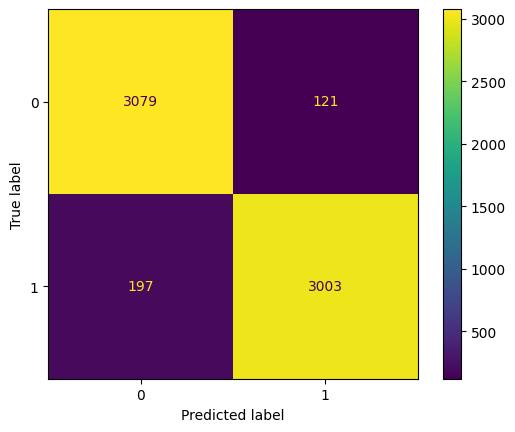

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix (TF-IDF + SVM):\n", ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm))

## COMPARISON TABLE

In [12]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["TF-IDF + SVM", "LSTM (Adam)"],
    "Accuracy": [accuracy_score(y_test, y_pred_svm),accuracy_score(y_test, y_pred_adam)],
    "Precision": [precision_score(y_test, y_pred_svm),precision_score(y_test, y_pred_adam)],
    "Recall": [recall_score(y_test, y_pred_svm),recall_score(y_test, y_pred_adam)],
    "F1-score": [f1_score(y_test, y_pred_svm),f1_score(y_test, y_pred_adam)]
})

print("\n-- FINAL COMPARISON --")
print(results)


-- FINAL COMPARISON --
          Model  Accuracy  Precision    Recall  F1-score
0  TF-IDF + SVM  0.950313   0.961268  0.938438  0.949715
1   LSTM (Adam)  0.969219   0.979559  0.958438  0.968883
